In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
nadia=cv2.imread('/Nadia_Murad.jpg')
denis=cv2.imread('/Denis_Mukwege.jpg')
solvay=cv2.imread('/solvay_conference.jpg')

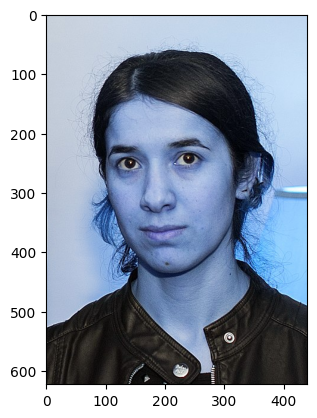

In [ ]:
if nadia is not None:
  plt.imshow(nadia,cmap='gray')
  plt.show()
else:
  print("Error: 'Nadia_Murad.jpg' could not be loaded. Please ensure the file exists and is in the correct directory.")

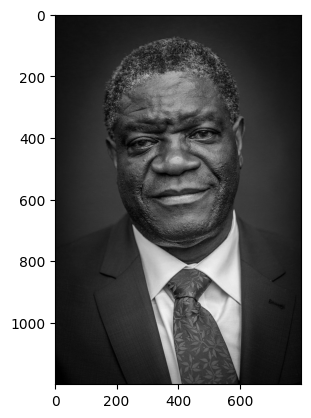

In [ ]:
plt.imshow(denis,cmap='gray')
plt.show()

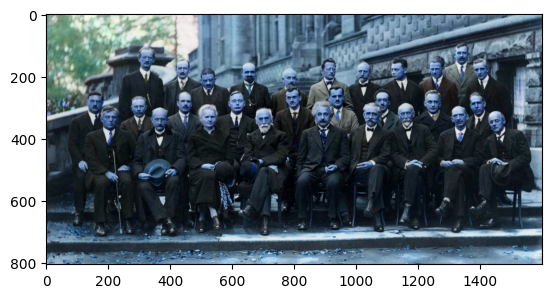

In [ ]:
plt.imshow(solvay,cmap='gray')
plt.show()

In [ ]:
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [ ]:
def detect_face(img):
  face_img=img.copy()
  face_rects=face_cascade.detectMultiScale(face_img)
  for (x,y,w,h) in face_rects:
    cv2.rectangle(face_img,(x,y),(x+w,y+h),(255,255,255),10)
  return face_img

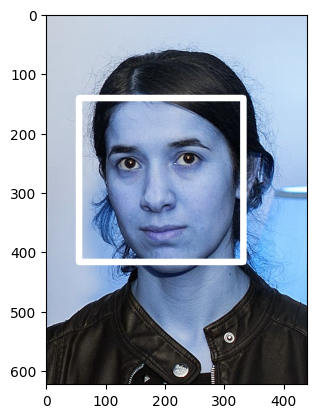

In [ ]:
result=detect_face(nadia)
plt.imshow(result,cmap='grey')
plt.show()

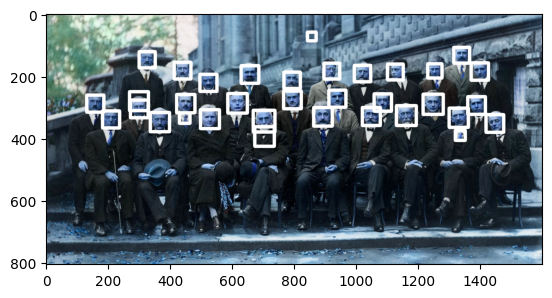

In [ ]:
result=detect_face(solvay)
plt.imshow(result,cmap='grey')
plt.show()

In [ ]:
eyecasc = cv2.CascadeClassifier('haarcascade_eye.xml')

In [ ]:
def detect_eye(img):
  faceimg = img.copy()
  eyes = eyecasc.detectMultiScale(faceimg,1.3,5)
  for(x,y,w,h) in eyes:
    cv2.rectangle(faceimg,(x,y),(x+w,y+h),(255,255,255),10)
  return faceimg

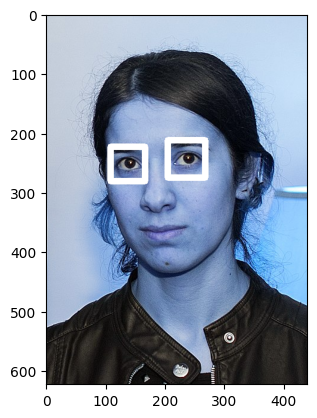

In [ ]:
if nadia is not None:
  if eyecasc.empty():
    print("Error: The eye cascade classifier was not loaded successfully.")
    print("Please ensure 'haarcascade_eye.xml' is available and cell 8gIsSZBYfLRS has been re-executed.")
    print("You might need to download it first: !wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml")
  else:
    res = detect_eye(nadia)
    plt.imshow(res,cmap='grey')
    plt.show()
else:
  print("Error: 'Nadia_Murad.jpg' could not be loaded. Please ensure the file exists and is in the correct directory.")

In [ ]:
#eyes = eyecasc.detectMultiScale(nadia,1.3,5)


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Frame';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for button to click
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

try:
  filename = take_photo()
  print(f'Saved to {filename}')

  # Read and display the image using OpenCV
  img = cv2.imread(filename)
  if img is not None:
    from google.colab.patches import cv2_imshow
    cv2_imshow(img)
  else:
    print("Error: Could not read the captured image.")

except Exception as err:
  print(str(err))
  print('You did not grant permission to use the camera, or no camera was found.')



<IPython.core.display.Javascript object>

NotFoundError: Requested device not found
You did not grant permission to use the camera, or no camera was found.


In [ ]:
import cv2
import time
cap = cv2.VideoCapture(0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
writer = cv2.VideoWriter('student_capture.mp4',cv2.VideoWriter_fourcc(*'XVID'),25,(width,height))

while True:
  ret,frame = cap.read()
  writer.write(frame)
  cv2.imshow('frame',frame)
  if cv2.waitKey(1) & 0xFF == ord('q'):
    break
cap.release()
writer.release()
writer.release()
cv2.destroyAllWindows()

DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow


In [ ]:
import cv2
import time

cap = cv2.VideoCapture('student_capture.mp4')

fps = 30

if(cap.isOpened()==False):
  print("Error" )
while cap.isOpened():
  ret,frame = cap.read()
  if ret==True:
    time.sleep(1/fps)
    cv2.imshow('frame',frame)
    if(cv2.waitKey(25) & 0xFF == ord('q')):
      break
  else:
    break
cap.release()
cv2.destroyAllWindows()


Error


In [ ]:
cap = cv2.VideoCapture(0)
while True:
  ret, frame = cap.read()
  cv2.imshow('frame',frame)
  if(cv2.waitKey(1) & 0xFF == ord('q')):
    break
cap.release()
cv2.destroyAllWindows()

DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow


# Task
Restart the Python runtime, then re-execute the cell that imports mediapipe and initializes its solutions to resolve the `AttributeError`.

## Restart Runtime

### Subtask:
Restart the Python runtime to ensure all installed packages and modules are correctly loaded.


## Restart Runtime

### Subtask:
Restart the Python runtime to ensure all installed packages and modules are correctly loaded.

#### Instructions
To restart the Python runtime, go to the Colab menu bar, click on 'Runtime', and then select 'Restart runtime'.

## Re-execute Mediapipe Import Cell

### Subtask:
After restarting the runtime, re-execute the cell containing the `mediapipe` import and solutions initialization to check if the error is resolved.


## Summary:

### Data Analysis Key Findings
*   The primary action taken was the generation of a markdown block providing instructions on how to manually restart the Python runtime within Google Colab.
*   The markdown block clearly instructed the user to navigate to 'Runtime' and then select 'Restart runtime' in the Colab menu bar.
*   The subtask of "Restart Runtime" was considered complete by successfully providing these manual instructions to the user, as the actual runtime restart is an action outside the agent's direct control.

### Insights or Next Steps
*   The user should now manually restart the Colab runtime by following the provided instructions.
*   After the runtime restart, the user needs to re-execute the cell containing the `mediapipe` import and solutions initialization to check if the `AttributeError` is resolved.
